# Import thư viện

In [1]:
import json # đọc file annotation từ JSON
import pandas as pd 
from collections import Counter # Đếm tần suất metadata
import math
import os
import random
import matplotlib.pyplot as plt


# Load data

In [ ]:
# Chuyển thư mục làm việc lên thư mục gốc
os.chdir("..")

# đọc 500 ảnh đầu tiên từ file bdd100k_labels_images_val.json 
with open("data/raw/annotations/bdd100k_labels_images_val.json", "r") as f:
    raw = json.load(f)

sample = raw[:500]
print(f"Tổng số ảnh trong value là: {len(raw)}")
print(f"Đang phân tích sample: {len(sample)} ảnh")

Tổng số ảnh trong value là: 10000
Đang phân tích sample: 500 ảnh


# Trích xuất metadata   

In [3]:
records = []

for image in sample:
    records.append({
        "filename" : image["name"],
        "weather" : image["attributes"]["weather"],
        "scene" : image["attributes"]["scene"],
        "timeofday" : image["attributes"]["timeofday"],
        "num_objects" : len(image["labels"])
    })

df = pd.DataFrame(records)
df.head(10)

,filename,weather,scene,timeofday,num_objects
0,b1c66a42-6f7d68ca.jpg,overcast,city street,daytime,51
1,b1c81faa-3df17267.jpg,clear,highway,night,17
2,b1c81faa-c80764c5.jpg,clear,highway,night,24
3,b1c9c847-3bda4659.jpg,undefined,city street,daytime,24
4,b1ca2e5d-84cf9134.jpg,clear,city street,night,42
5,b1ca8418-84a133a0.jpg,clear,city street,night,11
6,b1cac6a7-04e33135.jpg,rainy,city street,daytime,20
7,b1cd1e94-26dd524f.jpg,clear,city street,night,33
8,b1cd1e94-549d0bfe.jpg,undefined,city street,daytime,28
9,b1ceb32e-3f481b43.jpg,clear,city street,night,17


# Xem phân bổ metadata

In [4]:
# xem mỗi metadata có bao nhiêu giá trị khác nhau
print("Số giá trị khác nhau của Weather: ", df["weather"].value_counts())
print("Số giá trị khác nhau của Scene: ", df["scene"].value_counts())
print("Số giá trị khác nhau của Timeofday: ", df["timeofday"].value_counts())

Số giá trị khác nhau của Weather:  weather
clear            258
undefined         58
snowy             57
overcast          54
rainy             49
partly cloudy     23
foggy              1
Name: count, dtype: int64
Số giá trị khác nhau của Scene:  scene
city street     286
highway         135
residential      70
undefined         4
parking lot       3
tunnel            1
gas stations      1
Name: count, dtype: int64
Số giá trị khác nhau của Timeofday:  timeofday
daytime      258
night        190
dawn/dusk     50
undefined      2
Name: count, dtype: int64


# Viết hàm tính entropy

In [5]:
def calc_entropy(counter):
    # tính shannon entropy từ một counter
    total = sum(counter.values())
    entropy = 0.0
    
    for count in counter.values():
        p = count /total
        if p > 0:
            entropy -= p * math.log2(p)

    return entropy

# test thử
test_counter = Counter(({"clear": 3, "rainy": 1, "foggy": 1}))
print(f"Entropy test: {calc_entropy(test_counter):.4f}")

Entropy test: 1.3710


# Tính entropy thực tế trên sample

In [6]:
# tính entropy cho từng loại metadata
weather_entropy = calc_entropy(Counter(df["weather"]))
scene_entropy = calc_entropy(Counter(df["scene"]))
timeofday_entropy = calc_entropy(Counter(df["timeofday"]))

print(f"Entropy weather:    {weather_entropy:.4f}")
print(f"Entropy scene:      {scene_entropy:.4f}")
print(f"Entropy timeofday:  {timeofday_entropy:.4f}")

Entropy weather:    2.1077
Entropy scene:      1.5040
Entropy timeofday:  1.3871


# Mô phỏng hai batch để so sánh

In [7]:
random.seed(42)

# batch 1 ngẫu nhiên, mô phỏng batch đa dạng
batch_diverse = df.sample(n=20, random_state=42)

# batch 2 chọn một loại weather, mô phỏng batch đơn điệu
batch_homogeneous = df[df["weather"] == "clear"].head(20)

# So sánh entropy
print("Batch diverse:")
print(f"Weather distribution: {dict(Counter(batch_diverse["weather"]))}")
print(f"Entropy: {calc_entropy(Counter(batch_diverse["weather"]))}")

print("\nBatch homogeneous:")
print(f"Weather distribution: {dict(Counter(batch_homogeneous["weather"]))}")
print(f"Entropy: {calc_entropy(Counter(batch_homogeneous["weather"]))}")

Batch diverse:
Weather distribution: {'undefined': 3, 'clear': 9, 'snowy': 2, 'overcast': 2, 'rainy': 3, 'partly cloudy': 1}
Entropy: 2.219973094021975

Batch homogeneous:
Weather distribution: {'clear': 20}
Entropy: 0.0


# Trực quan hóa

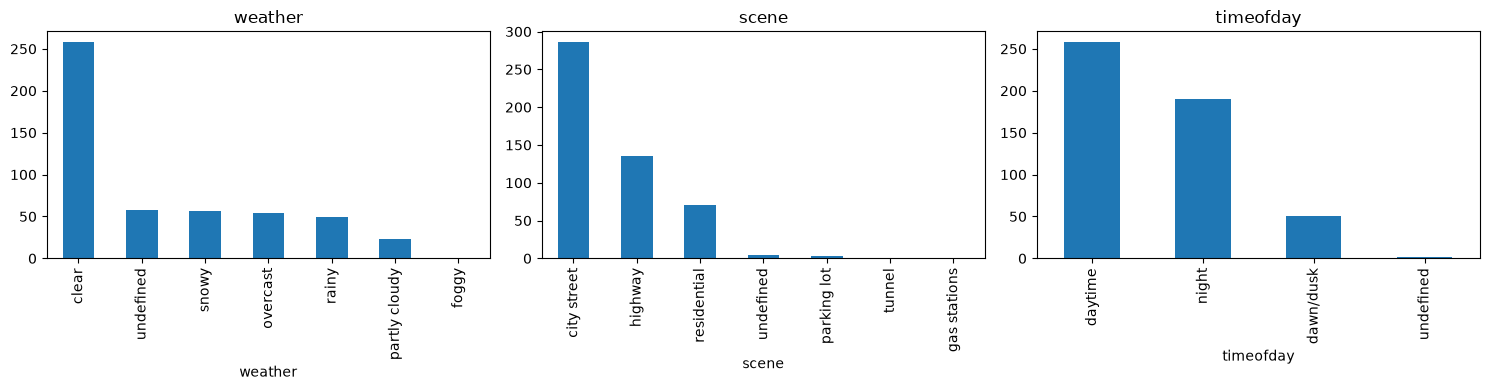

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["weather", "scene", "timeofday"]):
    df[col].value_counts().plot(kind="bar", ax=ax, title=col)

plt.tight_layout()
plt.show()